# Stat 565, HW 7
# Artem Ivaniuk

In [29]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, t

from statsmodels.tsa.arima_process import arma_generate_sample
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

warnings.filterwarnings('ignore')

Question 1 set up

In [30]:
# Simulate 400 observations from:
# (1 - 0.8B)(Δy_t - 1.6) = (1 + 0.6B)a_t, a_t ~ N(0, 1.5^2)

n = 400
sigma_a = 1.5

ar_poly = np.array([1, -0.8])
ma_poly = np.array([1, 0.6])

w = arma_generate_sample(ar=ar_poly, ma=ma_poly, nsample=n, scale=sigma_a)
x = 1.6 + w
y = np.cumsum(x)

sim_df = pd.DataFrame({'x_diff': x, 'y_level': y})
sim_df.head()

,x_diff,y_level
0,3.641703,3.641703
1,4.532914,8.174617
2,4.395722,12.570340
3,3.491505,16.061845
4,1.003871,17.065716


Question 1 (1)

In [31]:
# Method (1): Fit ARIMA(1,1,1) to y_t directly (no exog)
fit_m1 = ARIMA(y, order=(1, 1, 1), trend='n').fit()
fc_m1 = fit_m1.get_forecast(steps=12)

pred_m1 = pd.Series(fc_m1.predicted_mean, index=np.arange(1, 13), name='Method1_yhat')
pred_m1

1     620.271047
2     623.795434
3     626.695530
4     629.081917
5     631.045593
6     632.661432
7     633.991051
8     635.085147
9     635.985441
10    636.726262
11    637.335857
12    637.837472
Name: Method1_yhat, dtype: float64

Question 1 (2)

In [32]:
# Method (2): Fit ARMA(1,1) to x_t = Δy_t, then map forecasts back to y_t
fit_m2 = ARIMA(x, order=(1, 0, 1), trend='c').fit()
fc_x_m2 = fit_m2.get_forecast(steps=12).predicted_mean

y_last = y[-1]
pred_m2 = y_last + np.cumsum(fc_x_m2)
pred_m2 = pd.Series(pred_m2, index=np.arange(1, 13), name='Method2_yhat')
pred_m2

1     620.390946
2     624.211082
3     627.569094
4     630.560692
5     633.261762
6     635.732475
7     638.020540
8     640.163783
9     642.192199
10    644.129569
11    645.994750
12    647.802692
Name: Method2_yhat, dtype: float64

Question 1 (3)

In [33]:
# Method (3): ARIMA(1,1,1) on y_t with exogenous time trend (xreg analogue)
t = np.arange(1, n + 1)
fit_m3 = ARIMA(y, order=(1, 1, 1), exog=t, trend='n').fit()

future_t = np.arange(n + 1, n + 13)
fc_m3 = fit_m3.get_forecast(steps=12, exog=future_t)

pred_m3 = pd.Series(fc_m3.predicted_mean, index=np.arange(1, 13), name='Method3_yhat')
se_m3 = pd.Series(fc_m3.se_mean, index=np.arange(1, 13), name='Method3_se')

comp_p1 = pd.concat([pred_m1, pred_m2, pred_m3], axis=1)
comp_p1

,Method1_yhat,Method2_yhat,Method3_yhat
1,620.271047,620.390946,620.393742
2,623.795434,624.211082,624.219954
3,626.695530,627.569094,627.586389
4,629.081917,630.560692,630.588069
5,631.045593,633.261762,633.300378
6,632.661432,635.732475,635.783118
7,633.991051,638.020540,638.083735
8,635.085147,640.163783,640.239868
9,635.985441,642.192199,642.281377
10,636.726262,644.129569,644.231951


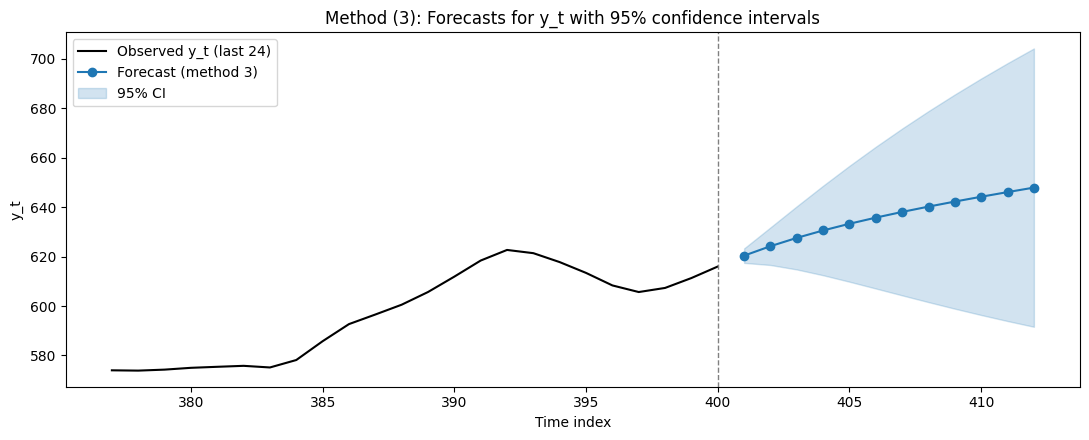

,Method3_yhat,Method3_se
1,620.393742,1.495473
2,624.219954,3.883968
3,627.586389,6.523950
4,630.588069,9.249386
5,633.300378,11.971062


In [34]:
# Plot last 24 observations, 12-step forecasts, and 95% CI for method (3)
last_24_idx = np.arange(n - 23, n + 1)
future_idx = np.arange(n + 1, n + 13)

ci_m3 = fc_m3.conf_int(alpha=0.05)
if isinstance(ci_m3, np.ndarray):
    ci_low = ci_m3[:, 0]
    ci_high = ci_m3[:, 1]
else:
    ci_low = ci_m3.iloc[:, 0].values
    ci_high = ci_m3.iloc[:, 1].values

plt.figure(figsize=(11, 4.5))
plt.plot(last_24_idx, y[-24:], label='Observed y_t (last 24)', color='black')
plt.plot(future_idx, pred_m3.values, marker='o', label='Forecast (method 3)', color='tab:blue')
plt.fill_between(future_idx, ci_low, ci_high, color='tab:blue', alpha=0.2, label='95% CI')
plt.axvline(n, color='gray', linestyle='--', linewidth=1)
plt.title('Method (3): Forecasts for y_t with 95% confidence intervals')
plt.xlabel('Time index')
plt.ylabel('y_t')
plt.legend()
plt.tight_layout()
plt.show()

pd.concat([pred_m3, se_m3], axis=1).head()

Question 1 (4)

In [35]:
# Check which methods match numerically
check_df = comp_p1.copy()
check_df['abs_diff_2_vs_3'] = np.abs(check_df['Method2_yhat'] - check_df['Method3_yhat'])
check_df['abs_diff_1_vs_2'] = np.abs(check_df['Method1_yhat'] - check_df['Method2_yhat'])
check_df['abs_diff_1_vs_3'] = np.abs(check_df['Method1_yhat'] - check_df['Method3_yhat'])

display(check_df)

print('Max |Method2 - Method3| =', check_df['abs_diff_2_vs_3'].max())
print('Max |Method1 - Method2| =', check_df['abs_diff_1_vs_2'].max())
print('Max |Method1 - Method3| =', check_df['abs_diff_1_vs_3'].max())

,Method1_yhat,Method2_yhat,Method3_yhat,abs_diff_2_vs_3,abs_diff_1_vs_2,abs_diff_1_vs_3
1,620.271047,620.390946,620.393742,0.002796,0.119899,0.122695
2,623.795434,624.211082,624.219954,0.008872,0.415648,0.424519
3,626.695530,627.569094,627.586389,0.017295,0.873564,0.890859
4,629.081917,630.560692,630.588069,0.027378,1.478774,1.506152
5,631.045593,633.261762,633.300378,0.038616,2.216170,2.254785
6,632.661432,635.732475,635.783118,0.050643,3.071043,3.121686
7,633.991051,638.020540,638.083735,0.063196,4.029489,4.092685
8,635.085147,640.163783,640.239868,0.076085,5.078636,5.154721
9,635.985441,642.192199,642.281377,0.089178,6.206758,6.295936
10,636.726262,644.129569,644.231951,0.102381,7.403308,7.505689


Max |Method2 - Method3| = 0.12889194078650235
Max |Method1 - Method2| = 9.965219735963387
Max |Method1 - Method3| = 10.09411167674989


Methods (2) and (3) are essentially the same (with a tiny numerical difference). Method (1) is different because no exogenous drift/trend term is included when fitting y_t directly

## Problem 2

In [36]:
# Read GE daily OHLC data
ge_path = Path('d-geohlc.txt')
ge = pd.read_csv(ge_path, sep=r'\s+', header=None)
ge.columns = ['year', 'month', 'day', 'open', 'high', 'low', 'close', 'volume', 'adj_close']
ge['date'] = pd.to_datetime(ge[['year', 'month', 'day']])
ge = ge.sort_values('date').reset_index(drop=True)
ge.head()

,year,month,day,open,high,low,close,volume,adj_close,date
0,1996,1,2,71.37,73.62,71.25,73.50,15397800,10.01,1996-01-02
1,1996,1,3,73.75,74.37,73.25,73.62,18469200,10.02,1996-01-03
2,1996,1,4,73.75,74.25,71.25,72.75,18659400,9.91,1996-01-04
3,1996,1,5,72.50,72.87,71.50,72.87,11625000,9.92,1996-01-05
4,1996,1,8,73.25,73.62,72.37,73.37,4343400,9.99,1996-01-08


Question 2 (1)

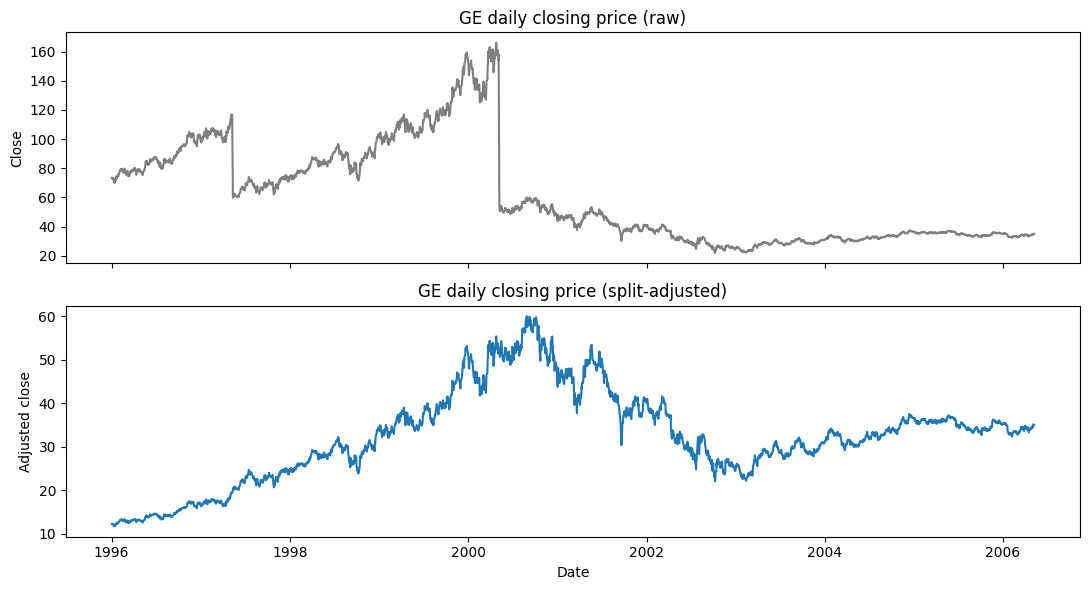

In [37]:
# Plot raw close and split-adjusted close
split1 = pd.Timestamp('1997-05-09')
split2 = pd.Timestamp('2000-05-05')

ge['close_adj_split'] = ge['close'].copy()
ge.loc[ge['date'] <= split1, 'close_adj_split'] = ge.loc[ge['date'] <= split1, 'close'] / 6.0
ge.loc[(ge['date'] > split1) & (ge['date'] <= split2), 'close_adj_split'] = ge.loc[(ge['date'] > split1) & (ge['date'] <= split2), 'close'] / 3.0
# instructions said to divide before split 1 and not include split2, but it then has a 1 day jump on both split dates, so included <= for split 1 and 2

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(ge['date'], ge['close'], color='tab:gray')
axes[0].set_title('GE daily closing price (raw)')
axes[0].set_ylabel('Close')

axes[1].plot(ge['date'], ge['close_adj_split'], color='tab:blue')
axes[1].set_title('GE daily closing price (split-adjusted)')
axes[1].set_ylabel('Adjusted close')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()

The raw close series has two visible jumps at split dates. After adjustment, those jumps largely disappear and the long-run movement is much more interpretable

Question 2 (2)

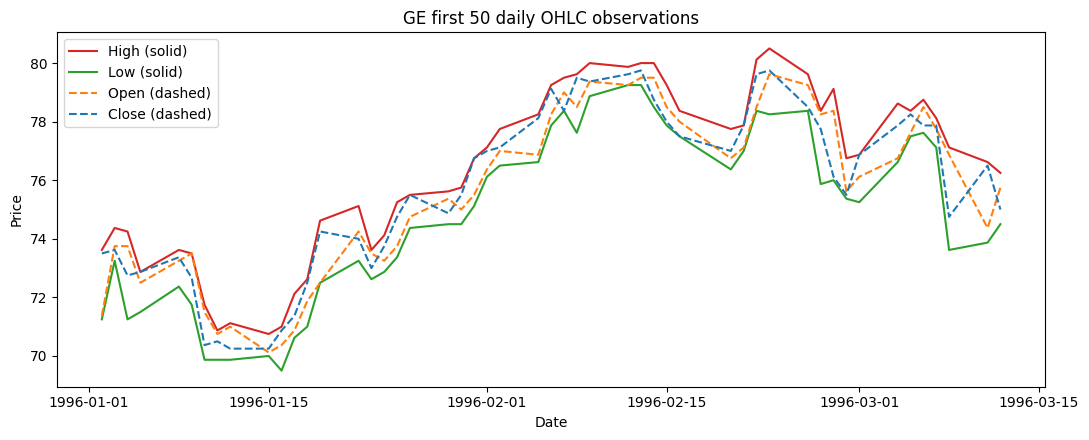

In [38]:
# First 50 observations of open/high/low/close on one figure
first50 = ge.iloc[:50]

plt.figure(figsize=(11, 4.5))
plt.plot(first50['date'], first50['high'], color='tab:red', linestyle='-', label='High (solid)')
plt.plot(first50['date'], first50['low'], color='tab:green', linestyle='-', label='Low (solid)')
plt.plot(first50['date'], first50['open'], color='tab:orange', linestyle='--', label='Open (dashed)')
plt.plot(first50['date'], first50['close'], color='tab:blue', linestyle='--', label='Close (dashed)')
plt.title('GE first 50 daily OHLC observations')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

As expected, daily high and low form an envelope around open and close. Open/close track inside that band with similar short-run dynamics

Question 2 (3)

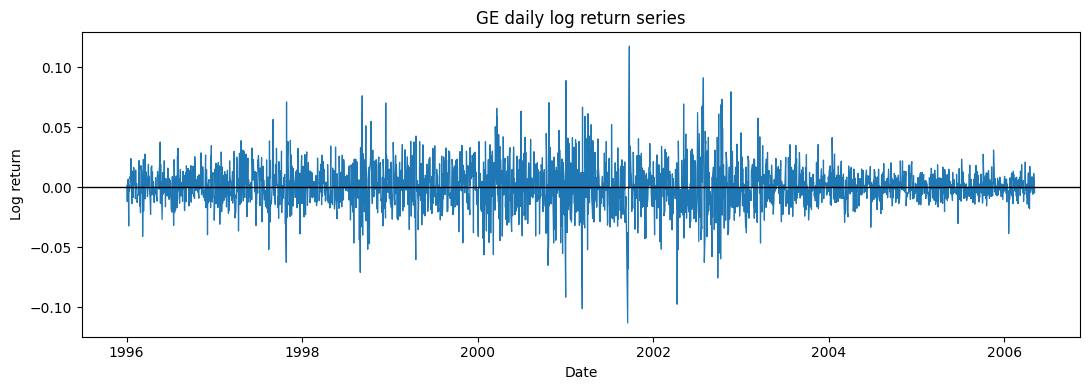

count    2604.000000
mean        0.000403
std         0.018450
min        -0.112871
25%        -0.009468
50%         0.000000
75%         0.010488
max         0.117428
Name: ret, dtype: float64

In [39]:
# Daily log return using split-adjusted close
ge['log_close_adj'] = np.log(ge['close_adj_split'])
ge['ret'] = ge['log_close_adj'].diff()
ret = ge['ret'].dropna()

plt.figure(figsize=(11, 4))
plt.plot(ge.loc[ret.index, 'date'], ret, color='tab:blue', linewidth=0.9)
plt.axhline(0, color='black', linewidth=1)
plt.title('GE daily log return series')
plt.xlabel('Date')
plt.ylabel('Log return')
plt.tight_layout()
plt.show()

ret.describe()

The return series fluctuates around zero with periods of high and low volatility, suggesting volatility clustering

Question 2 (4)

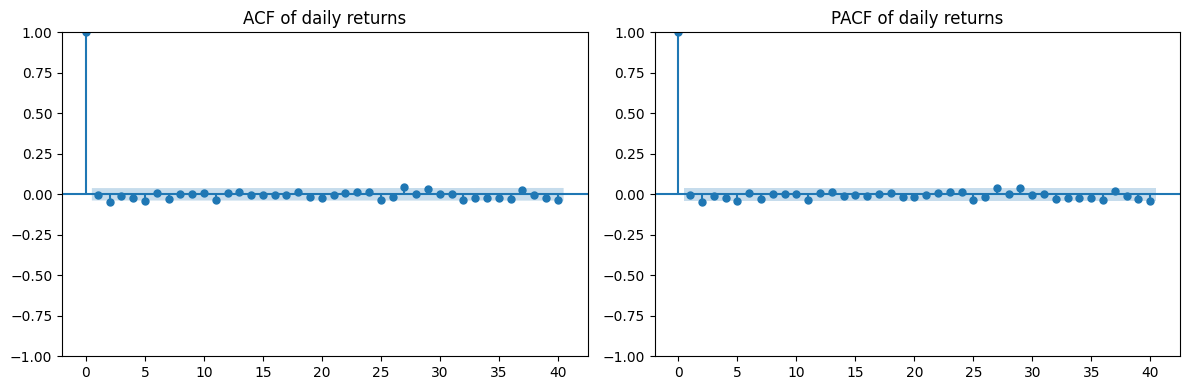

In [40]:
# ACF and PACF of returns
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(ret, lags=40, ax=axes[0])
plot_pacf(ret, lags=40, ax=axes[1], method='ywm')
axes[0].set_title('ACF of daily returns')
axes[1].set_title('PACF of daily returns')
plt.tight_layout()
plt.show()

The return autocorrelations are small overall, with only mild short-lag dependence. This suggests a low-order ARMA model for the mean is reasonable -- we find this to be true in the next step with ARMA(1,2) being the best fit

Question 2 (5)

In [41]:
# Fit candidate ARMA(p,q) models and choose by AIC + Ljung-Box
candidates = []
arma_fits = {}

for p in range(0, 4):
    for q in range(0, 4):
        if p == 0 and q == 0:
            continue
        try:
            fit = ARIMA(ret, order=(p, 0, q), trend='c').fit()
            resid = fit.resid
            lb_p = float(acorr_ljungbox(resid, lags=[20], model_df=(p+q), return_df=True)['lb_pvalue'].iloc[0])
            candidates.append({'model': f'ARMA({p},{q})', 'p': p, 'q': q, 'AIC': fit.aic, 'LjungBox_p_lag20': lb_p})
            arma_fits[(p, q)] = fit
        except Exception:
            pass

arma_table = pd.DataFrame(candidates).sort_values('AIC').reset_index(drop=True)
display(arma_table.head(10))

best = arma_table.iloc[0]
best_p, best_q = int(best['p']), int(best['q'])
best_name = best['model']
best_fit = arma_fits[(best_p, best_q)]
mean_resid = best_fit.resid

print('Selected mean model:', best_name)
print(best_fit.summary())

,model,p,q,AIC,LjungBox_p_lag20
0,"ARMA(1,2)",1,2,-13404.686981,0.742576
1,"ARMA(2,2)",2,2,-13403.809155,0.750677
2,"ARMA(0,2)",0,2,-13403.433165,0.607820
3,"ARMA(2,0)",2,0,-13403.118965,0.589458
4,"ARMA(0,3)",0,3,-13401.944315,0.569832
5,"ARMA(3,3)",3,3,-13401.924289,0.785452
6,"ARMA(2,1)",2,1,-13401.726427,0.556740
7,"ARMA(2,3)",2,3,-13401.601090,0.668680
8,"ARMA(3,0)",3,0,-13401.377000,0.533584
9,"ARMA(1,3)",1,3,-13400.317449,0.523577


Selected mean model: ARMA(1,2)
                               SARIMAX Results                                
Dep. Variable:                    ret   No. Observations:                 2604
Model:                 ARIMA(1, 0, 2)   Log Likelihood                6707.343
Date:                Tue, 21 Apr 2026   AIC                         -13404.687
Time:                        15:48:54   BIC                         -13375.363
Sample:                             0   HQIC                        -13394.063
                               - 2604                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0004      0.000      1.214      0.225      -0.000       0.001
ar.L1          0.5769      0.163      3.549      0.000       0.258       0.896
ma.L1         -0.5840

I pick the ARMA model with the smallest AIC among stable fitted candidates -- ARMA(1, 2) -- and check residual whiteness with Ljung-Box

Question 2 (6)

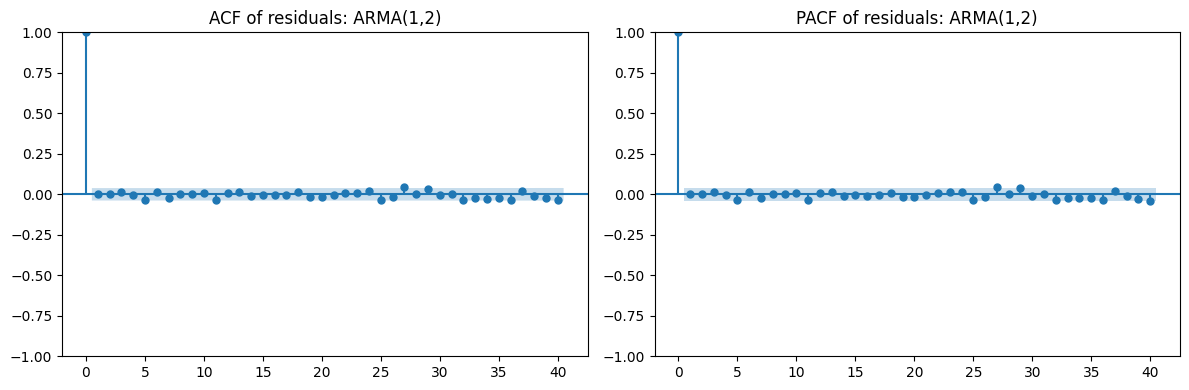

In [42]:
# ACF/PACF of ARMA residuals
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(mean_resid, lags=40, ax=axes[0])
plot_pacf(mean_resid, lags=40, ax=axes[1], method='ywm')
axes[0].set_title(f'ACF of residuals: {best_name}')
axes[1].set_title(f'PACF of residuals: {best_name}')
plt.tight_layout()
plt.show()

Residual autocorrelation is weak after fitting the ARMA mean model, indicating the mean dynamics are mostly absorbed

Question 2 (7)

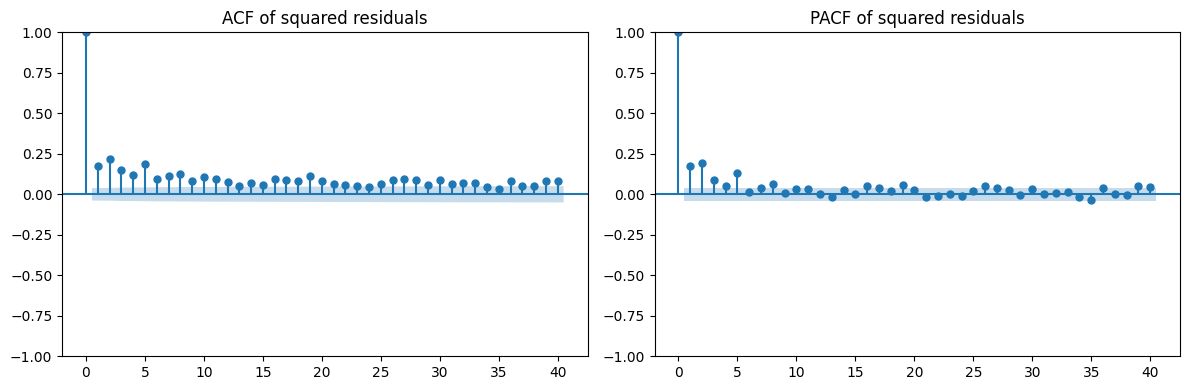

In [43]:
# ACF/PACF of squared ARMA residuals
sq_resid = mean_resid**2

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(sq_resid, lags=40, ax=axes[0])
plot_pacf(sq_resid, lags=40, ax=axes[1], method='ywm')
axes[0].set_title('ACF of squared residuals')
axes[1].set_title('PACF of squared residuals')
plt.tight_layout()
plt.show()

The squared residual autocorrelations are clearly more pronounced than in raw residuals, which is evidence of conditional heteroskedasticity and suggests that we should do GARCH-type variance modeling

Question 2 (8)

In [44]:
# Fit GARCH models on ARMA residuals (normal first), then compare with t errors
try:
    from arch import arch_model
except ImportError as e:
    raise ImportError("Please install the 'arch' package before running Question 2 (8)-(10): pip install arch") from e

# Scale residuals for numerical stability in arch fitting
resid_scale = mean_resid * 100

garch_rows = []
garch_fits = {}
for p in [1, 2]:
    for q in [1, 2]:
        try:
            gfit = arch_model(resid_scale, mean='Zero', vol='GARCH', p=p, q=q, dist='normal').fit(disp='off')
            garch_rows.append({'model': f'GARCH({p},{q})-Normal', 'p': p, 'q': q, 'AIC': gfit.aic, 'BIC': gfit.bic})
            garch_fits[(p, q, 'normal')] = gfit
        except Exception:
            pass

garch_table = pd.DataFrame(garch_rows).sort_values('AIC').reset_index(drop=True)
display(garch_table)

best_garch = garch_table.iloc[0]
bp, bq = int(best_garch['p']), int(best_garch['q'])
fit_garch_norm = garch_fits[(bp, bq, 'normal')]
fit_garch_t = arch_model(resid_scale, mean='Zero', vol='GARCH', p=bp, q=bq, dist='t').fit(disp='off')

print('Selected normal model by AIC:', f'GARCH({bp},{bq})-Normal')
print('\nNormal errors fit summary:')
print(fit_garch_norm.summary())
print('\nStudent-t errors fit summary:')
print(fit_garch_t.summary())

if fit_garch_t.aic < fit_garch_norm.aic:
    final_garch = fit_garch_t
    final_dist = 't'
else:
    final_garch = fit_garch_norm
    final_dist = 'normal'

print('\nFinal variance model:', f'GARCH({bp},{bq}) with {final_dist} errors')

,model,p,q,AIC,BIC
0,"GARCH(1,1)-Normal",1,1,9936.776443,9954.370855
1,"GARCH(1,2)-Normal",1,2,9937.782933,9961.242149
2,"GARCH(2,1)-Normal",2,1,9938.776444,9962.235660
3,"GARCH(2,2)-Normal",2,2,9940.127027,9969.451047


Selected normal model by AIC: GARCH(1,1)-Normal

Normal errors fit summary:
                       Zero Mean - GARCH Model Results                        
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -4965.39
Distribution:                  Normal   AIC:                           9936.78
Method:            Maximum Likelihood   BIC:                           9954.37
                                        No. Observations:                 2604
Date:                Tue, Apr 21 2026   Df Residuals:                     2604
Time:                        15:48:54   Df Model:                            0
                               Volatility Model                              
                 coef    std err          t      P>|t|       95.0% Conf. Int.
---------------------------------------------------------

I start from normal-error GARCH(p,q) candidates and select the best by information criteria, then compare against the same order with t errors. The final model Garch(1, 1) has the better fit and sensible parameter estimates

Question 2 (9)

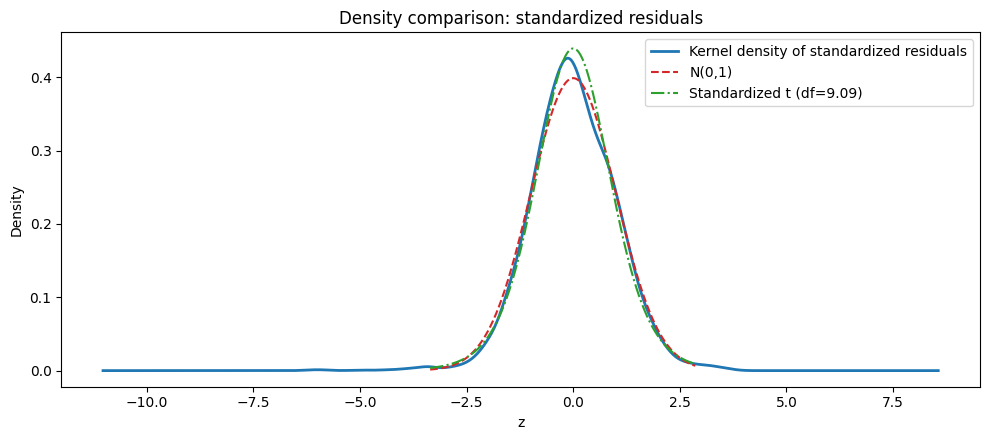

In [45]:
# Standardized residual density vs Normal (and standardized t if selected)
from scipy.stats import t as student_t

std_resid = pd.Series(final_garch.std_resid).dropna()

xgrid = np.linspace(std_resid.quantile(0.005), std_resid.quantile(0.995), 400)

plt.figure(figsize=(10, 4.5))
std_resid.plot(kind='kde', linewidth=2, label='Kernel density of standardized residuals')
plt.plot(xgrid, norm.pdf(xgrid, loc=0, scale=1), '--', label='N(0,1)', color='tab:red')

if final_dist == 't':
    nu = float(final_garch.params.get('nu', np.nan))
    if np.isfinite(nu) and nu > 2:
        scale = np.sqrt((nu - 2) / nu)
        plt.plot(xgrid, student_t.pdf(xgrid / scale, df=nu) / scale, '-.', color='tab:green',
                 label=f'Standardized t (df={nu:.2f})')

plt.title('Density comparison: standardized residuals')
plt.xlabel('z')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

The residual density is compared to N(0,1), and to standardized t if the t-GARCH model is selected. Any heavier tails in the empirical density relative to normal indicate non-Gaussian shock behavior

Question 2 (10)

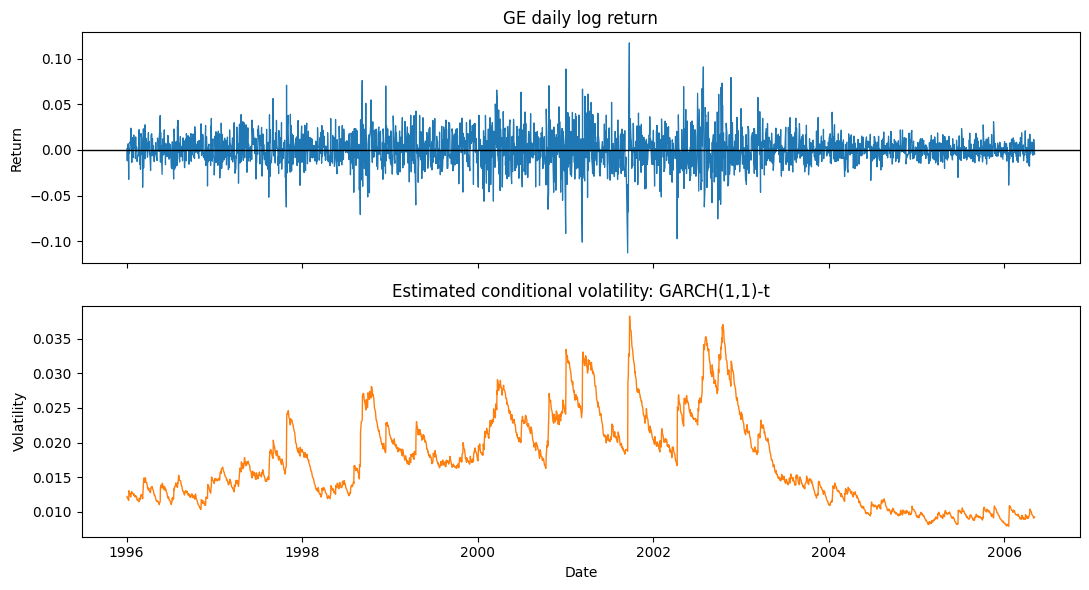

In [46]:
# Plot return series and estimated volatility on same page
cond_vol = pd.Series(final_garch.conditional_volatility, index=mean_resid.index) / 100.0

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(ge.loc[mean_resid.index, 'date'], ret.loc[mean_resid.index], color='tab:blue', linewidth=0.9)
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('GE daily log return')
axes[0].set_ylabel('Return')

axes[1].plot(ge.loc[mean_resid.index, 'date'], cond_vol, color='tab:orange', linewidth=1)
axes[1].set_title(f'Estimated conditional volatility: GARCH({bp},{bq})-{final_dist}')
axes[1].set_ylabel('Volatility')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()

Estimated volatility rises during turbulent periods and falls during calm periods, consistent with volatility clustering visible in the return plot